LOAD DATASET

In [1]:
import pandas as pd

path_file = r'D:\Jupyter\Proyek Data Mining\Dataset\Dataset_XAUUSD.csv'

df = pd.read_csv(path_file)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print("Data Berhasil Dimuat!")
print(f"Total Baris: {len(df):,}")
print(f"Total Kolom: {len(df.columns)}")
display(df.head())

Data Berhasil Dimuat!
Total Baris: 5,977,088
Total Kolom: 6


,Timestamp,Open,High,Low,Close,Volume
0,2009-03-15 17:00:00,929.60,929.60,929.60,929.60,0
1,2009-03-15 18:00:00,925.85,927.00,925.80,926.05,0
2,2009-03-15 18:01:00,925.80,927.30,925.80,925.90,0
3,2009-03-15 18:02:00,925.90,926.45,925.90,925.90,0
4,2009-03-15 18:03:00,925.85,926.95,925.85,926.95,0


DATA DESCRIPTION

In [2]:
print("Jumlah Baris & Kolom:")
print(f"Jumlah Baris: {df.shape[0]:,}")
print(f"Jumlah Kolom: {df.shape[1]}")

Jumlah Baris & Kolom:
Jumlah Baris: 5,977,088
Jumlah Kolom: 6


In [3]:
print("Tipe Data Setiap Atribut:")
print(df.dtypes)

Tipe Data Setiap Atribut:
Timestamp    datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Volume                int64
dtype: object


In [4]:
print("Statistik Deskriptif:")
display(df[['Open', 'High', 'Low', 'Close']].describe())

Statistik Deskriptif:


,Open,High,Low,Close
count,5.977088e+06,5.977088e+06,5.977088e+06,5.977088e+06
mean,1.683486e+03,1.683755e+03,1.683215e+03,1.683487e+03
std,7.130190e+02,7.132404e+02,7.127890e+02,7.130201e+02
min,8.610000e+02,8.657500e+02,8.610000e+02,8.653800e+02
25%,1.252790e+03,1.252930e+03,1.252660e+03,1.252790e+03
50%,1.475827e+03,1.475970e+03,1.475685e+03,1.475825e+03
75%,1.825928e+03,1.826164e+03,1.825688e+03,1.825928e+03
max,5.593005e+03,5.596805e+03,5.590855e+03,5.593005e+03


DATA EXPLORATION

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 150

VISUALISASI TREN HARGA

C:\Users\acer\AppData\Local\Temp\ipykernel_13972\3125859428.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


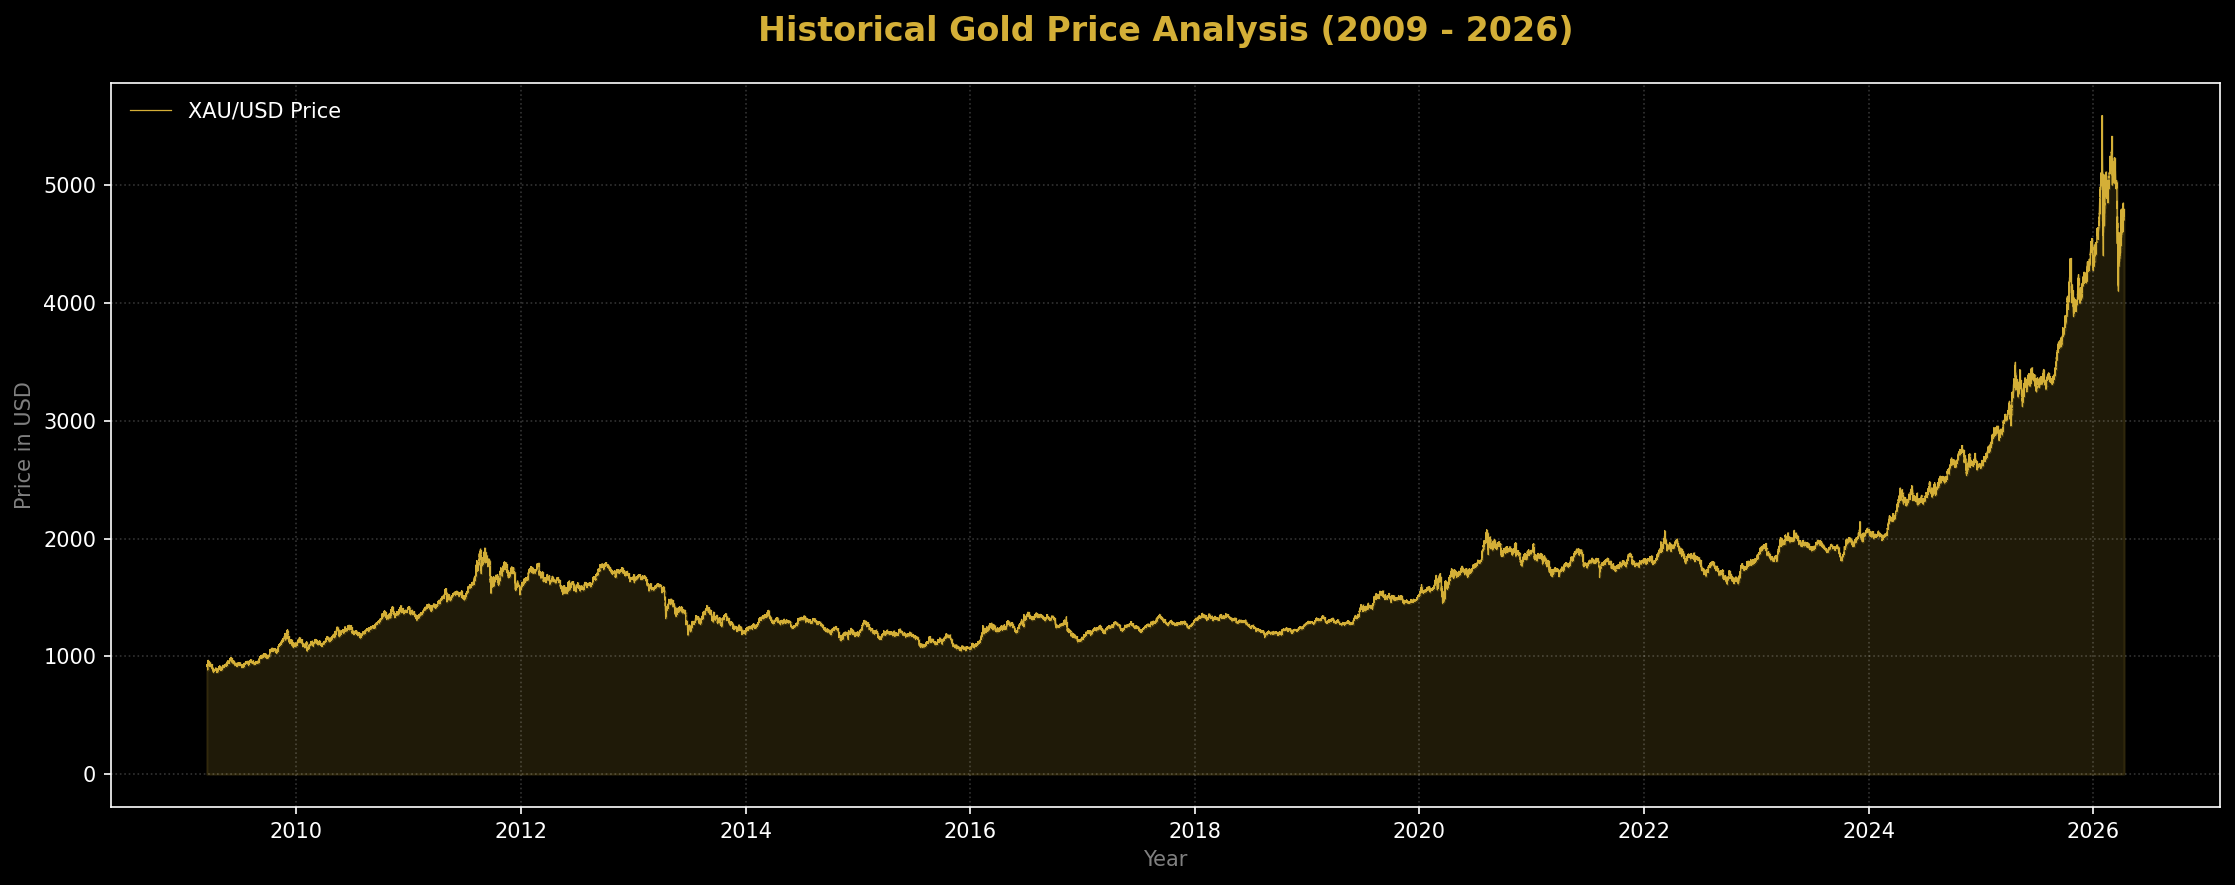

In [17]:
plt.figure(figsize=(15, 6))
plt.fill_between(df['Timestamp'], df['Close'], color="#D4AF37", alpha=0.15) # Bayangan emas
plt.plot(df['Timestamp'], df['Close'], color="#D4AF37", linewidth=0.6, label='XAU/USD Price')

plt.title('Historical Gold Price Analysis (2009 - 2026)', fontsize=16, color='#D4AF37', pad=20, fontweight='bold')
plt.xlabel('Year', color='gray')
plt.ylabel('Price in USD', color='gray')
plt.grid(True, linestyle=':', alpha=0.2) # Grid halus
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

DISTRIBUSI & KORELASI

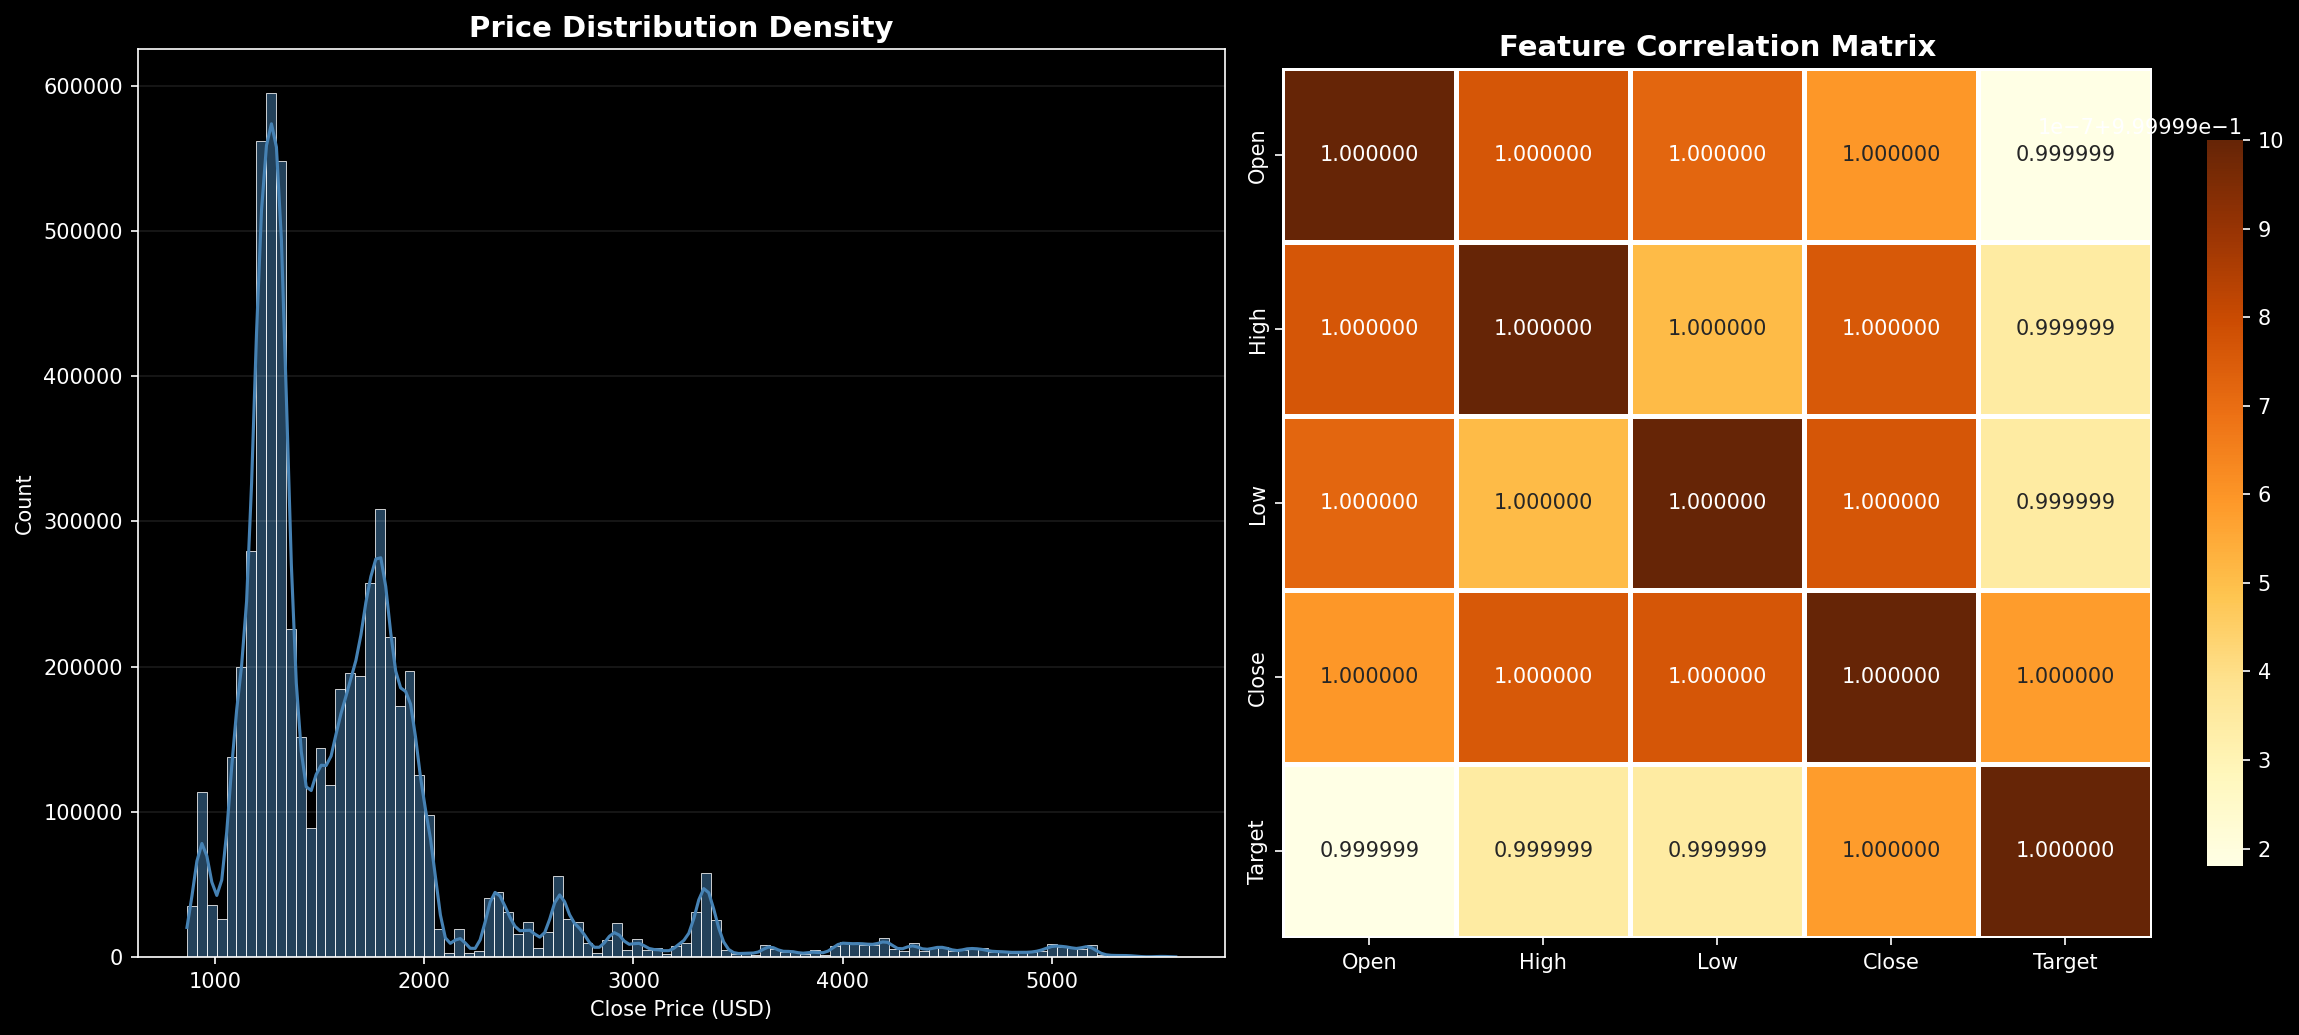

In [24]:
df['Target'] = df['Close'].shift(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Histogram Distribusi
sns.histplot(df['Close'], kde=True, color='#4682B4', bins=100, ax=ax1)
ax1.set_title('Price Distribution Density', fontsize=14, color='white', fontweight='bold')
ax1.set_xlabel('Close Price (USD)')
ax1.grid(axis='y', alpha=0.1)

# Heatmap Korelasi
korelasi = df[['Open', 'High', 'Low', 'Close', 'Target']].corr()

sns.heatmap(korelasi, annot=True, cmap='YlOrBr', fmt='.6f', 
            square=True, linewidths=1.5, cbar_kws={"shrink": .8}, ax=ax2)
ax2.set_title('Feature Correlation Matrix', fontsize=14, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Melihat korelasi dengan presisi 10 angka di belakang koma
print(df[['Open', 'High', 'Low', 'Close', 'Target']].corr().to_string(float_format=lambda x: "{:.10f}".format(x)))

               Open         High          Low        Close       Target
Open   1.0000000000 0.9999997633 0.9999997194 0.9999995943 0.9999991800
High   0.9999997633 1.0000000000 0.9999995076 0.9999997597 0.9999993459
Low    0.9999997194 0.9999995076 1.0000000000 0.9999997638 0.9999993449
Close  0.9999995943 0.9999997597 0.9999997638 1.0000000000 0.9999995815
Target 0.9999991800 0.9999993459 0.9999993449 0.9999995815 1.0000000000


DATA QUALITY ASSESMENT 

In [39]:
import pandas as pd
path = r'D:\Jupyter\Proyek Data Mining\Dataset\Dataset_XAUUSD.csv'
df_raw = pd.read_csv(path)

In [41]:
print("Cek Missing Values")
print(df_raw.isnull().sum())

Cek Missing Values
Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64


In [43]:
print("Cek Data Duplikat")
duplikat_count = df_raw.duplicated(subset=['Timestamp']).sum()
print(f"Jumlah baris duplikat: {duplikat_count}")

Cek Data Duplikat
Jumlah baris duplikat: 420


In [44]:
# Menampilkan contoh baris yang memiliki Timestamp duplikat
df_duplikat_detail = df[df.duplicated(subset=['Timestamp'], keep=False)]
print(df_duplikat_detail.sort_values('Timestamp').head(10))

                  Timestamp      Open      High       Low     Close  Volume  \
3737375 2019-10-27 19:00:00  1503.925  1504.135  1503.825  1504.095       0   
3737376 2019-10-27 19:00:00  1503.925  1504.135  1503.825  1504.095       0   
3737377 2019-10-27 19:01:00  1504.065  1504.465  1504.065  1504.435       0   
3737378 2019-10-27 19:01:00  1504.065  1504.465  1504.065  1504.435       0   
3737379 2019-10-27 19:02:00  1504.475  1504.535  1504.368  1504.378       0   
3737380 2019-10-27 19:02:00  1504.475  1504.535  1504.368  1504.378       0   
3737381 2019-10-27 19:03:00  1504.378  1504.378  1504.198  1504.358       0   
3737382 2019-10-27 19:03:00  1504.378  1504.378  1504.198  1504.358       0   
3737383 2019-10-27 19:04:00  1504.358  1504.458  1504.258  1504.288       0   
3737384 2019-10-27 19:04:00  1504.358  1504.458  1504.258  1504.288       0   

           Target  
3737375  1504.095  
3737376  1504.435  
3737377  1504.435  
3737378  1504.378  
3737379  1504.378  
3737380  1

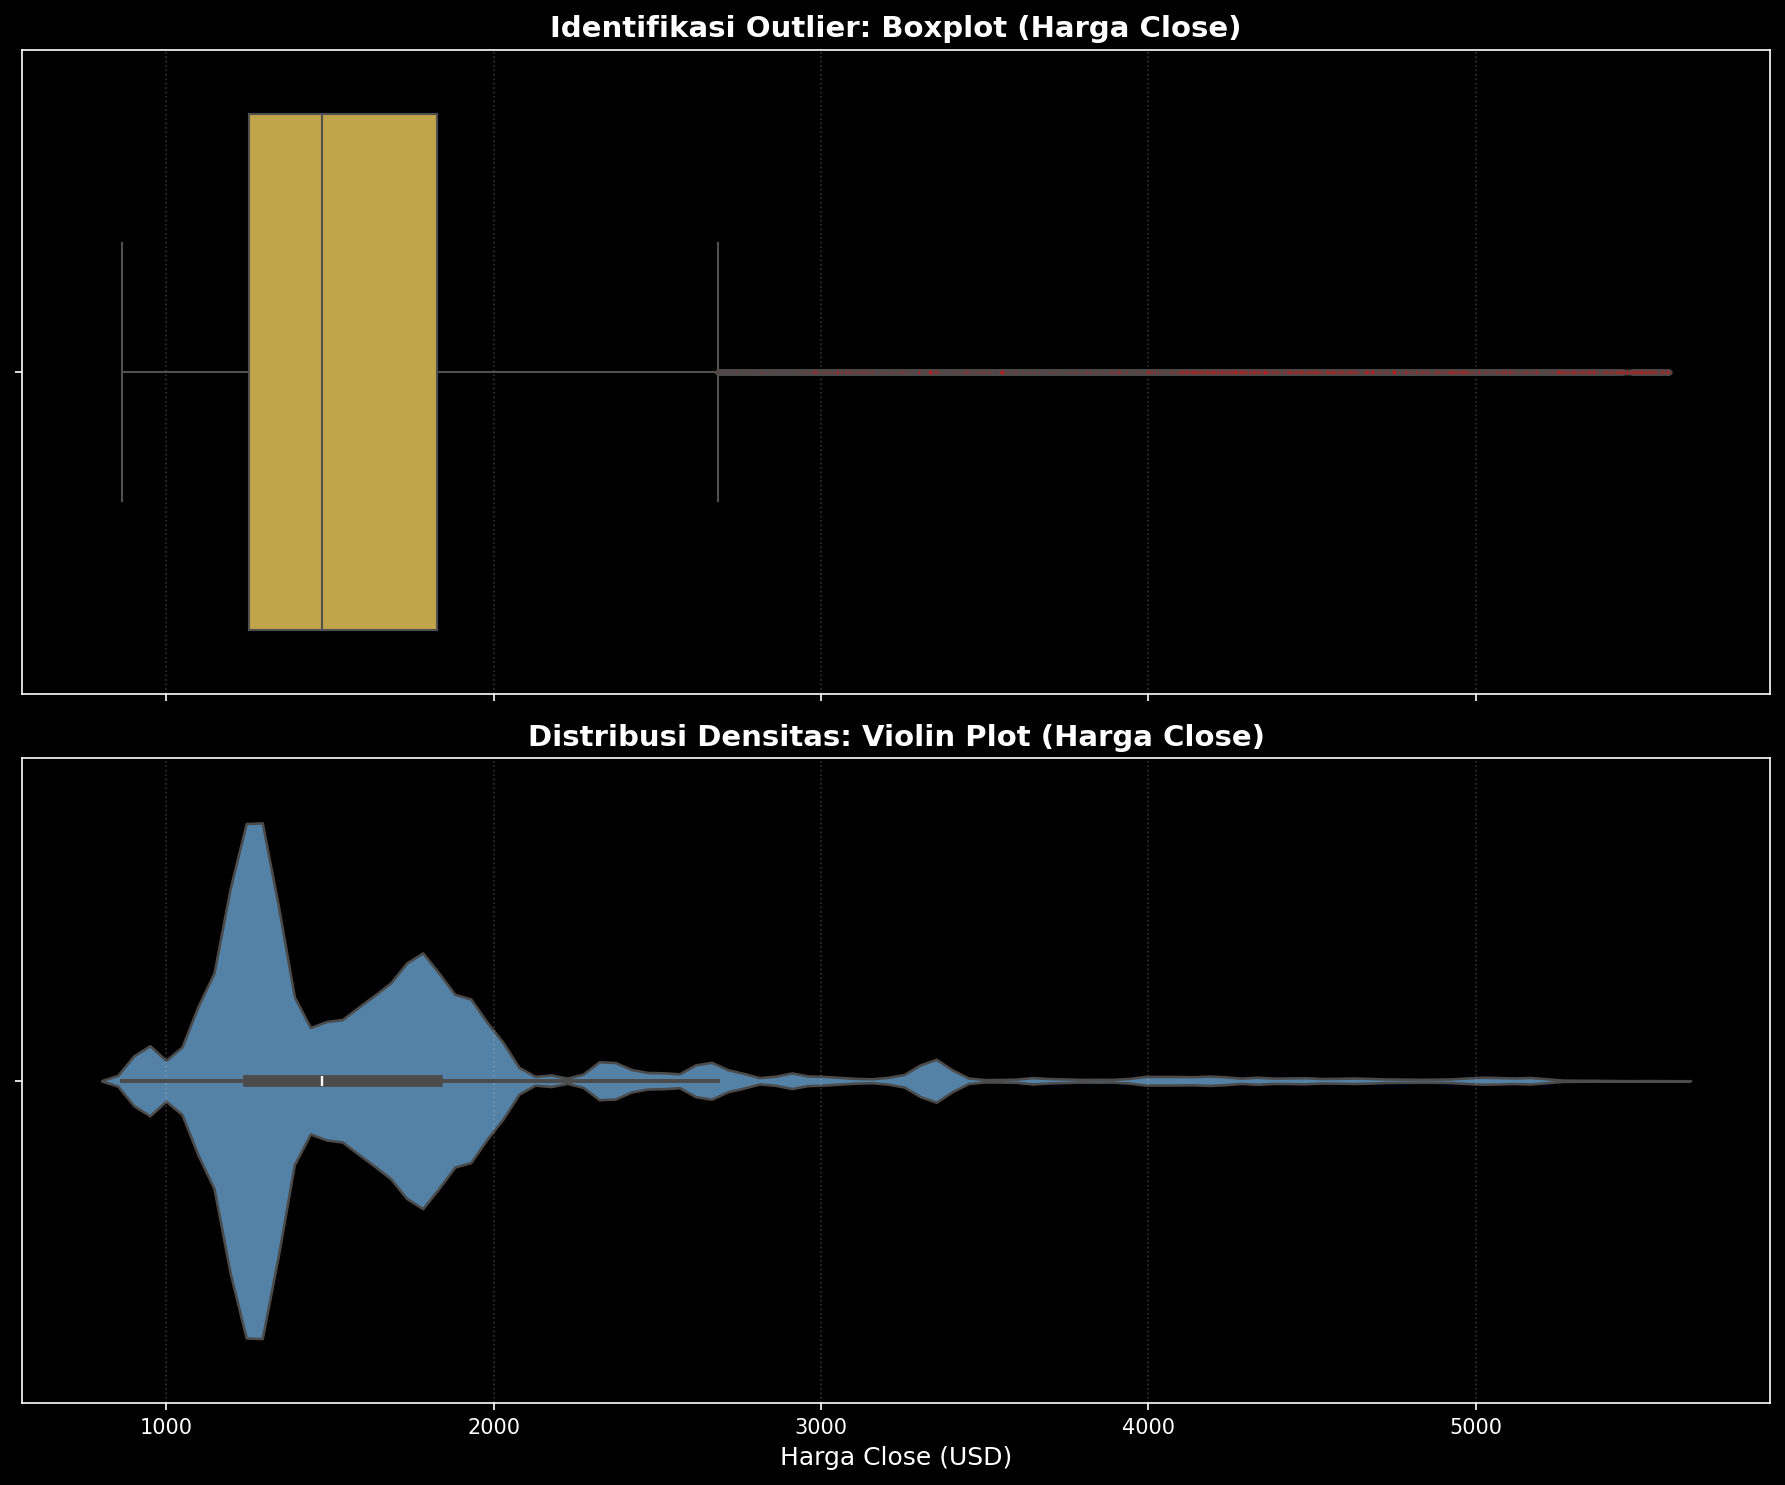

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# BOXPLOT (Untuk melihat batas statistik & titik outlier secara tegas)
sns.boxplot(x=df['Close'], color='#D4AF37', fliersize=2, ax=ax1,
            flierprops=dict(markerfacecolor='red', marker='o', alpha=0.2))
ax1.set_title('Identifikasi Outlier: Boxplot (Harga Close)', fontsize=14, color='white', fontweight='bold')
ax1.grid(axis='x', linestyle=':', alpha=0.2)

# VIOLIN PLOT (Untuk melihat "kepadatan" data - di mana massa data menumpuk)
sns.violinplot(x=df['Close'], color='#4682B4', ax=ax2)
ax2.set_title('Distribusi Densitas: Violin Plot (Harga Close)', fontsize=14, color='white', fontweight='bold')
ax2.grid(axis='x', linestyle=':', alpha=0.2)

plt.xlabel('Harga Close (USD)', color='white', fontsize=12)
plt.tick_params(colors='white')

plt.tight_layout()
plt.show()

In [34]:
outlier_ekstrem = df[df['Close'] > 3000]
print(f"Jumlah outlier ekstrem: {len(outlier_ekstrem)}")
print(outlier_ekstrem)

Jumlah outlier ekstrem: 376050
                  Timestamp      Open      High       Low     Close  Volume  \
5597713 2025-03-14 05:12:00  2999.725  3001.035  2999.725  3000.895       0   
5597714 2025-03-14 05:13:00  3000.855  3000.855  3000.358  3000.675       0   
5597715 2025-03-14 05:14:00  3000.675  3000.765  3000.375  3000.715       0   
5597716 2025-03-14 05:15:00  3000.715  3001.615  3000.595  3001.455       0   
5597717 2025-03-14 05:16:00  3001.478  3003.245  3001.425  3003.155       0   
...                     ...       ...       ...       ...       ...     ...   
5977083 2026-04-10 16:54:00  4748.955  4749.548  4747.458  4748.715       0   
5977084 2026-04-10 16:55:00  4748.675  4749.218  4745.625  4748.825       0   
5977085 2026-04-10 16:56:00  4749.075  4749.818  4748.198  4748.818       0   
5977086 2026-04-10 16:57:00  4748.198  4750.265  4747.998  4748.855       0   
5977087 2026-04-10 16:58:00  4748.895  4749.295  4747.998  4748.615       0   

           Target  
